In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from decimal import Decimal

In [2]:
# Load the dataset

columns = [
    'Problem Name', 
    'Graph-based?',
    'Algo # (within problem)', 
    'Name/Source',
    'Runtime',
    '10^10 compute (regular/sparse)',
    '10^10 compute (dense)',
    '10^15 compute (regular/sparse)',
    '10^15 compute (dense)',
    '10^20 compute (regular/sparse)',
    '10^20 compute (dense)',
    '10^25 compute (regular/sparse)',
    '10^25 compute (dense)',
    '10^30 compute (regular/sparse)',
    '10^30 compute (dense)',
    'Approx factor',
    '(approx factor relative position)'
]
approximation_algorithms = pd.read_csv('approx_runtime.csv', usecols=columns,
                                      dtype = {'10^10 compute (regular/sparse)': float,
                                              '10^15 compute (regular/sparse)': float,
                                              '10^20 compute (regular/sparse)': float,
                                              '10^25 compute (regular/sparse)': float,
                                              '10^30 compute (regular/sparse)': float,
                                              '10^10 compute (dense)': float,
                                              '10^15 compute (dense)': float,
                                              '10^20 compute (dense)': float,
                                              '10^25 compute (dense)': float,
                                              '10^30 compute (dense)': float})


# drop empty family names
approximation_algorithms = approximation_algorithms[approximation_algorithms['Problem Name'].notnull()]

for col in ['(approx factor relative position)']:
    # Extract numeric (float) from string
    approximation_algorithms[col] = approximation_algorithms[col].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
    #approximation_algorithms[col] = approximation_algorithms[col].replace(0, 99999)
    

#approximation_algorithms.sort_values(by=['Problem Name', 'Algo # (within problem)'], inplace=True)

approximation_algorithms.to_csv('approx_runtime_processed.csv')

approximation_algorithms

,Problem Name,Graph-based?,Algo # (within problem),Name/Source,Runtime,10^10 compute (regular/sparse),10^10 compute (dense),10^15 compute (regular/sparse),10^15 compute (dense),10^20 compute (regular/sparse),10^20 compute (dense),10^25 compute (regular/sparse),10^25 compute (dense),10^30 compute (regular/sparse),10^30 compute (dense),Approx factor,(approx factor relative position)
0,Maximum Flow,Y,1.00,NaN,NaN,46992.0,2154.0,13060000.0,100000.0,3.745000e+09,4641000.0,1.094000e+12,215400000.0,3.240000e+14,1.000000e+10,1,1.00
1,Maximum Flow,Y,2.00,NaN,NaN,168321.0,2595.0,195900000.0,165975.0,2.749000e+11,11120000.0,4.266000e+14,764600000.0,7.051000e+17,5.342000e+10,1-eps,1.01
2,Maximum Flow,Y,3.00,NaN,NaN,11449.0,453.0,8466000.0,24769.0,8.848000e+09,1634000.0,1.108000e+13,119300000.0,1.550000e+16,9.269000e+09,1-eps,1.01
3,Maximum Flow,Y,4.00,NaN,NaN,905.0,61.0,374993.0,1302.0,2.867000e+08,36652.0,2.949000e+11,1184000.0,3.592000e+14,4.148000e+07,1-eps,1.01
4,Maximum Flow,Y,5.00,NaN,NaN,282.0,40.0,94821.0,869.0,8.936000e+07,28608.0,1.418000e+11,1181000.0,3.038000e+14,5.583000e+07,1-eps,1.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Graph Coloring,Y,3.65,NaN,NaN,104.0,104.0,156.0,156.0,2.080000e+02,208.0,2.610000e+02,261.0,3.130000e+02,3.130000e+02,2.3,2.30
195,Graph Coloring,Y,3.66,NaN,NaN,106.0,106.0,159.0,159.0,2.130000e+02,213.0,2.660000e+02,266.0,3.190000e+02,3.190000e+02,2.32,2.32
196,Graph Coloring,Y,3.67,NaN,NaN,108.0,108.0,163.0,163.0,2.170000e+02,217.0,2.710000e+02,271.0,3.260000e+02,3.260000e+02,2.34,2.34
197,Graph Coloring,Y,3.68,NaN,NaN,110.0,110.0,166.0,166.0,2.210000e+02,221.0,2.770000e+02,277.0,3.320000e+02,3.320000e+02,2.36,2.36


In [3]:
def fill_best_algo(df, column):
    best = []
    last_best = 0
    for index, row in df.iterrows():
        if row[column] > last_best:
            best.append(True)
            last_best = row[column]
        else:
            best.append(False)

    return best

def log_transform(df, column):
    logs = []
    for index, row in df.iterrows():
        logs.append(math.log10(row[column]))
    return logs

def plot_family_only_20(family, dense = False):
    
    df = approximation_algorithms.copy()

    df = df[df['Problem Name'] == family]
    df.sort_values(
        by=['(approx factor relative position)', '10^20 compute (regular/sparse)'], 
        ascending=[True, False],
        inplace=True
    )

    col_name = "10^20 compute (regular/sparse)"
    if dense:
        col_name = "10^20 compute (dense)"
    # Reduce opcity of point that are not the best
    df['Best'] = fill_best_algo(df, col_name)
    df['logs'] = log_transform(df, col_name)
    
    
    
    plt.figure(figsize=(8, 6))
    # hide in legend
    plt.scatter(df['(approx factor relative position)'], df['logs'], color='#DD444422')

    if len(df) > 0:
        best_approximate = df[df['Best']]
        #last_row = best_approximate.iloc[-1:].copy()
        #last_row['(approx factor relative position)'] = 10
        #best_approximate = pd.concat([best_approximate, last_row], ignore_index=True)
        plt.scatter(best_approximate['(approx factor relative position)'], best_approximate['logs'], color='#DD4444')
        last_row = best_approximate.iloc[-1:].copy()
        last_row['(approx factor relative position)'] = 9
        best_approximate = pd.concat([best_approximate, last_row], ignore_index=True)
        plt.step(best_approximate['(approx factor relative position)'], best_approximate['logs'], where='post', color='#DD4444')
    
        plt.fill_between(best_approximate['(approx factor relative position)'], 0, best_approximate['logs'], step='post', facecolor='#DD444450')


    plt.yticks(np.arange(0, 21, 2), ['$10^{'+str(i)+'}$' for i in range(0, 21, 2)])
    plt.xticks(np.arange(1, 10, 1), ['$1$', '$2$', '$C_{>2}$', '$\log\log(n)$', '$\log(n)$', '$poly\log(n)$', '$\sqrt{n}$', '$n$', '$\omega(n)$'])

    
    plt.xlabel('Approx Factor')
    plt.ylabel('Klam Value')
    #plt.yscale('log',base=10)
    plt.ylim(-0.5, 20.5)
    #plt.legend()
    if dense:
        title = family+" (dense)"
    else:
        title = family
    plt.title(title)
    
    #plt.tight_layout()
    #plt.savefig(title+'.png', bbox_inches='tight')
    plt.show()


In [6]:
colors = ['#F8AC30', '#E72A76', '#874996', '#00A3C9', '#7EBC57']

def get_best_values(df, column):
    best = []
    last_best = 0
    for index, row in df.iterrows():
        if row[column] > last_best:
            last_best = row[column]
        best.append(last_best)

    return best

def fill_best_or_matching_algo(df, column):
    best = []
    last_best = 0
    for index, row in df.iterrows():
        if row[column] >= last_best:
            best.append(True)
            last_best = row[column]
        else:
            best.append(False)

    return best

def plot_family(family, dense = False, xlimleft = 0.5, xlimright = 8.5, ylimbottom = -0.5, ylimtop = 31):
    
    df = approximation_algorithms.copy()

    df = df[df['Problem Name'] == family]
    df.sort_values(
        by=['(approx factor relative position)', '10^20 compute (regular/sparse)'], 
        ascending=[True, False],
        inplace=True
    )
    
    plt.figure(figsize=(8, 6))

    compute_strings = ["10^10", "10^15", "10^20", "10^25", "10^30"]
    for i in range(len(compute_strings)):
        
        compute_string = compute_strings[i]
        col_name = compute_string+" compute (regular/sparse)"
        if dense:
            col_name = compute_string+" compute (dense)"
        # Reduce opcity of point that are not the best
        df['Best'+compute_string] = fill_best_algo(df, col_name)
        df['Best values'+compute_string] = get_best_values(df, col_name)
        df['Max'+compute_string] = fill_best_or_matching_algo(df, col_name)
        df['logs'+compute_string] = log_transform(df, col_name)
        df['best logs'+compute_string] = log_transform(df, 'Best values'+compute_string)
    
        # hide in legend
        plt.scatter(df['(approx factor relative position)'], df['logs'+compute_string], color=colors[i]+'22')

    if len(df) > 0:
        for i in range(len(compute_strings)):
            compute_string = compute_strings[i]
            best_approximate = df[df['Best'+compute_string]]
            best_approximate_filter = best_approximate[best_approximate['Algo # (within problem)'] % 1.0 == 0.0]
            plt.scatter(best_approximate_filter['(approx factor relative position)'], best_approximate_filter['logs'+compute_string], color=colors[i])
            
            max_approximate = df.copy()
            last_row = max_approximate.iloc[-1:].copy()
            last_row['(approx factor relative position)'] = 9
            max_approximate = pd.concat([max_approximate, last_row], ignore_index=True)
            plt.step(max_approximate['(approx factor relative position)'], max_approximate['best logs'+compute_string], where='post', color=colors[i])
    
            if i == 0:
                plt.fill_between(max_approximate['(approx factor relative position)'], -0.5, max_approximate['best logs'+compute_string], step='post', facecolor=colors[i]+'50')
            else:
                prev_compute_string = compute_strings[i-1]
                plt.fill_between(max_approximate['(approx factor relative position)'], max_approximate['best logs'+prev_compute_string], max_approximate['best logs'+compute_string], step='post', facecolor=colors[i]+'50')
               

    plt.yticks(np.arange(0, 31, 2), ['$10^{'+str(i)+'}$' for i in range(0, 31, 2)])
    plt.xticks(np.arange(1, 9, 1), ['$1$', '$2$', 'large $C$', '$\log\log(n)$', '$\log(n)$', '$poly\log(n)$', '$\sqrt{n}$', '$n$'])

    
    plt.xlabel('Approx Factor')
    plt.ylabel('Largest Solvable Instance')
    #plt.yscale('log',base=10)
    plt.xlim(xlimleft, xlimright)
    plt.ylim(ylimbottom, ylimtop)
    #plt.legend()
    if dense:
        title = family+" (dense)"
    else:
        title = family
    plt.title(title)
    
    plt.tight_layout()
    plt.savefig(title+' (all).png', bbox_inches='tight')
    plt.show()
    
def plot_family_no_save(family, dense = False, xlimleft = 0.5, xlimright = 8.5, ylimbottom = -0.5, ylimtop = 31):
    
    df = approximation_algorithms.copy()

    df = df[df['Problem Name'] == family]
    df.sort_values(
        by=['(approx factor relative position)', '10^20 compute (regular/sparse)'], 
        ascending=[True, False],
        inplace=True
    )
    
    plt.figure(figsize=(8, 6))

    compute_strings = ["10^10", "10^15", "10^20", "10^25", "10^30"]
    for i in range(len(compute_strings)):
        
        compute_string = compute_strings[i]
        col_name = compute_string+" compute (regular/sparse)"
        if dense:
            col_name = compute_string+" compute (dense)"
        # Reduce opcity of point that are not the best
        df['Best'+compute_string] = fill_best_algo(df, col_name)
        df['Best values'+compute_string] = get_best_values(df, col_name)
        df['Max'+compute_string] = fill_best_or_matching_algo(df, col_name)
        df['logs'+compute_string] = log_transform(df, col_name)
        df['best logs'+compute_string] = log_transform(df, 'Best values'+compute_string)
    
        # hide in legend
        plt.scatter(df['(approx factor relative position)'], df['logs'+compute_string], color=colors[i]+'22')

    if len(df) > 0:
        for i in range(len(compute_strings)):
            compute_string = compute_strings[i]
            best_approximate = df[df['Best'+compute_string]]
            best_approximate_filter = best_approximate[best_approximate['Algo # (within problem)'] % 1.0 == 0.0]
            plt.scatter(best_approximate_filter['(approx factor relative position)'], best_approximate_filter['logs'+compute_string], color=colors[i])
            
            max_approximate = df.copy()
            last_row = max_approximate.iloc[-1:].copy()
            last_row['(approx factor relative position)'] = 9
            max_approximate = pd.concat([max_approximate, last_row], ignore_index=True)
            plt.step(max_approximate['(approx factor relative position)'], max_approximate['best logs'+compute_string], where='post', color=colors[i])
    
            if i == 0:
                plt.fill_between(max_approximate['(approx factor relative position)'], -0.5, max_approximate['best logs'+compute_string], step='post', facecolor=colors[i]+'50')
            else:
                prev_compute_string = compute_strings[i-1]
                plt.fill_between(max_approximate['(approx factor relative position)'], max_approximate['best logs'+prev_compute_string], max_approximate['best logs'+compute_string], step='post', facecolor=colors[i]+'50')
                

    plt.yticks(np.arange(0, 51, 2), ['$10^{'+str(i)+'}$' for i in range(0, 51, 2)])
    plt.xticks(np.arange(1, 9, 1), ['$1$', '$2$', 'large $C$', '$\log\log(n)$', '$\log(n)$', '$poly\log(n)$', '$\sqrt{n}$', '$n$'])

    
    plt.xlabel('Approx Factor')
    plt.ylabel('Largest Solvable Instance')
    #plt.yscale('log',base=10)
    plt.xlim(xlimleft, xlimright)
    plt.ylim(ylimbottom, ylimtop)
    #plt.legend()
    if dense:
        title = family+" (dense)"
    else:
        title = family
    plt.title(title)
    
    plt.show()

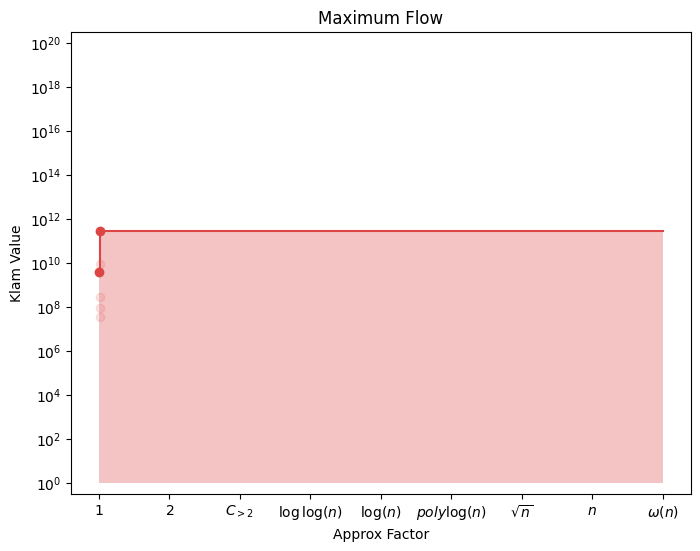

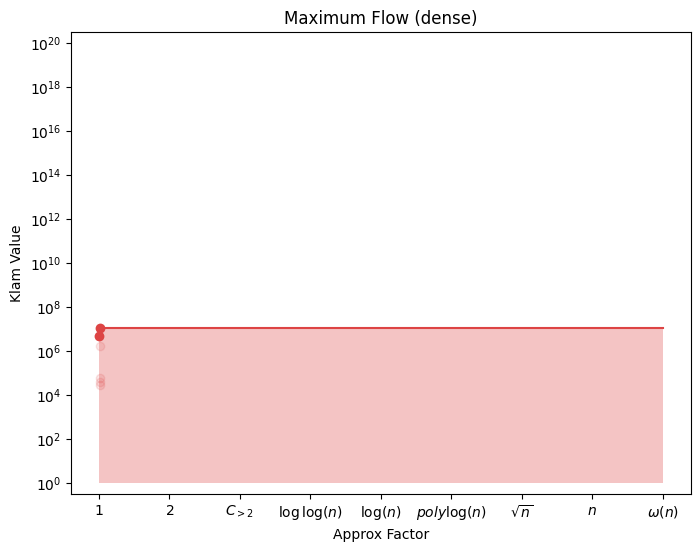

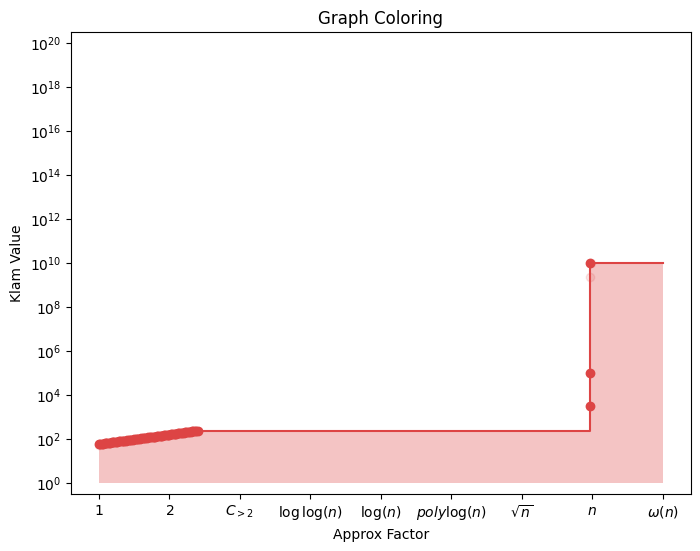

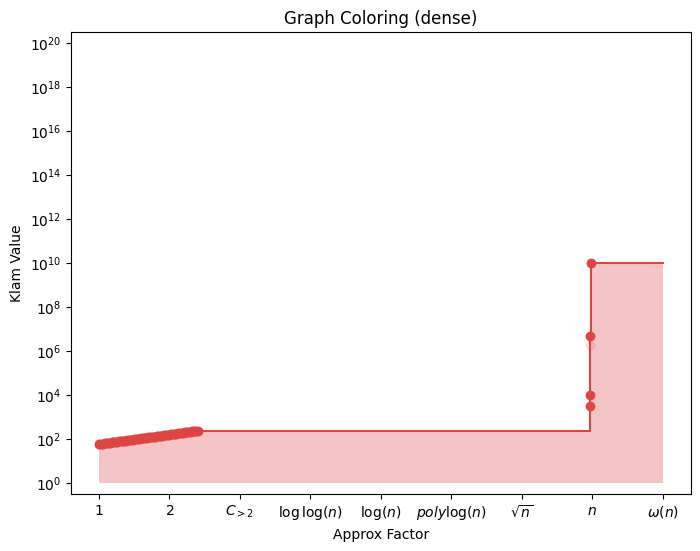

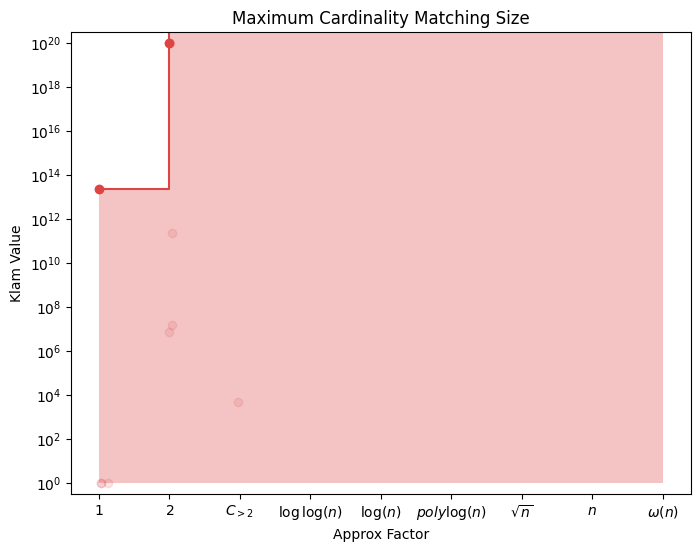

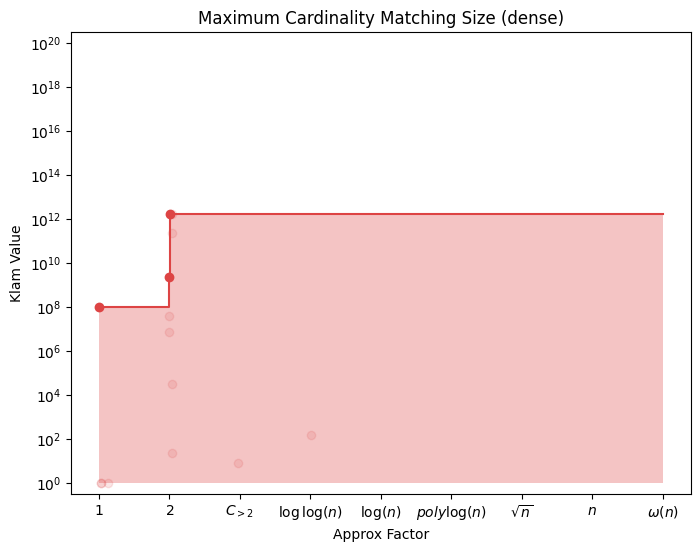

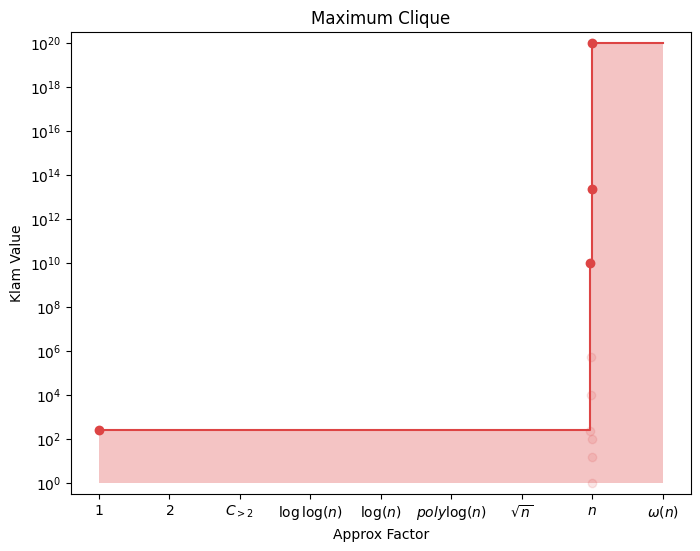

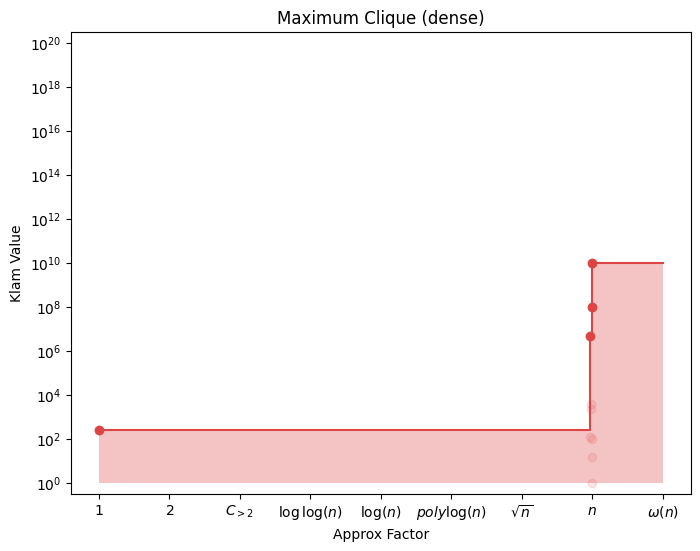

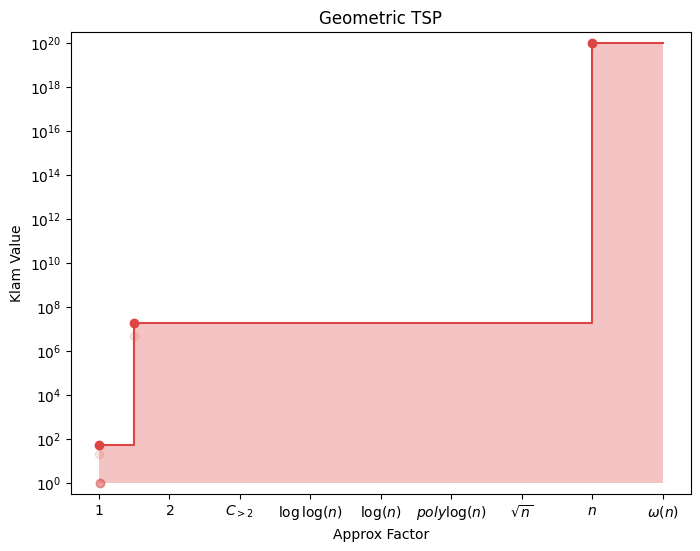

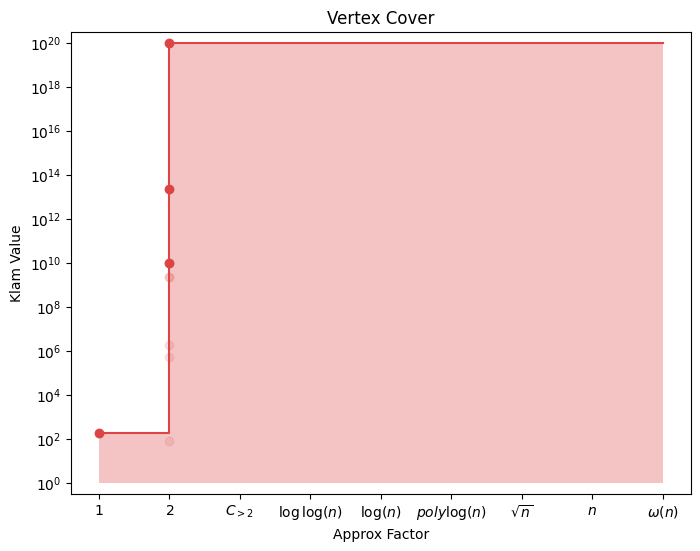

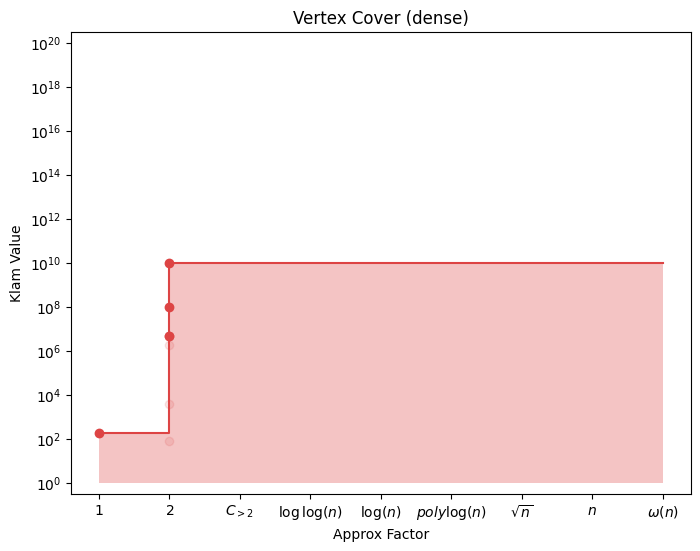

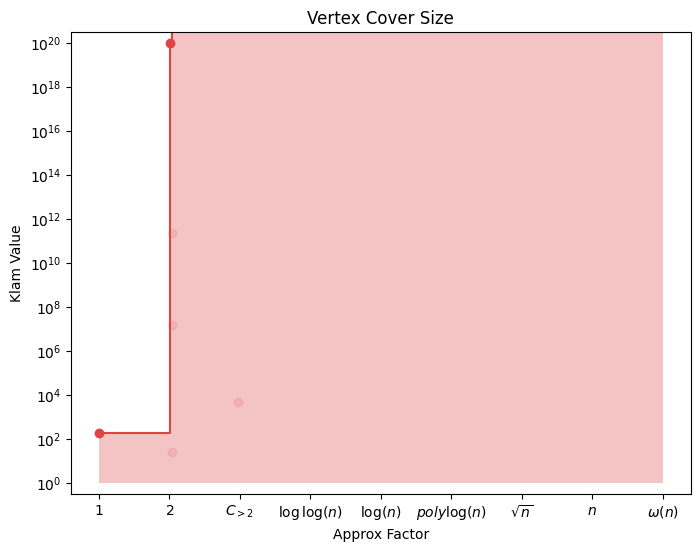

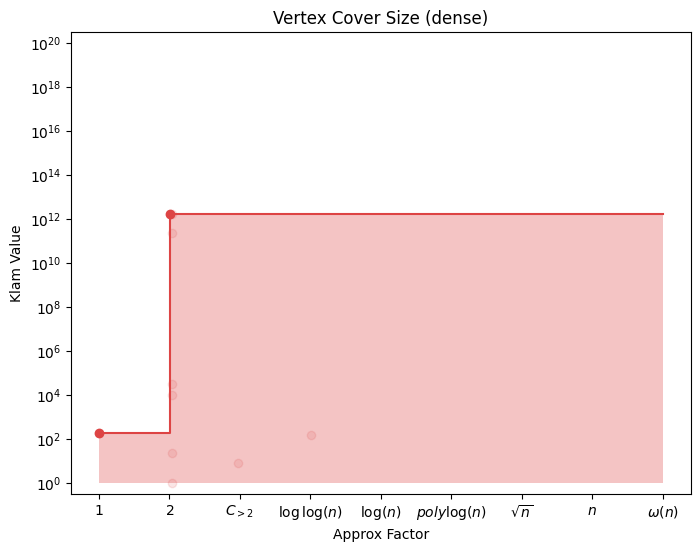

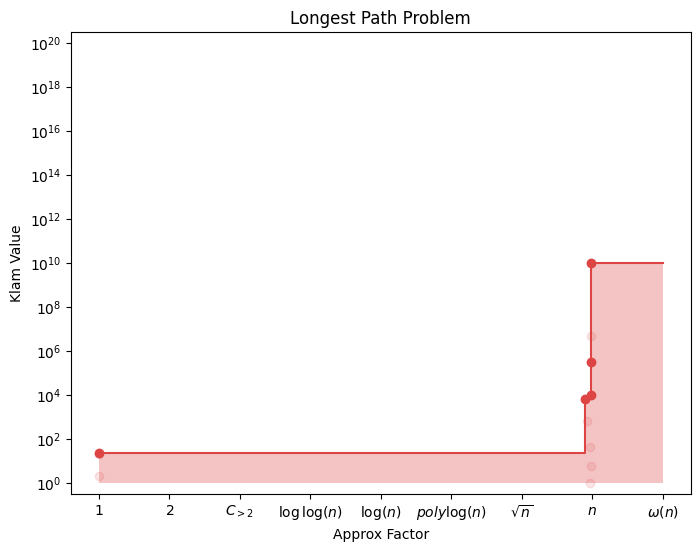

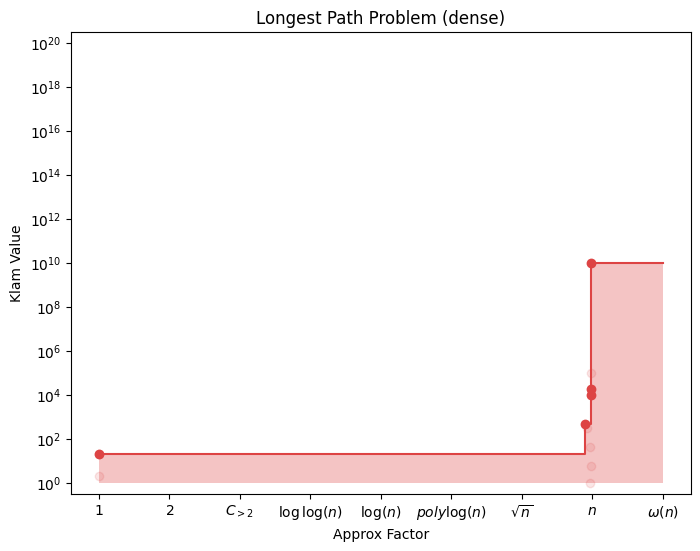

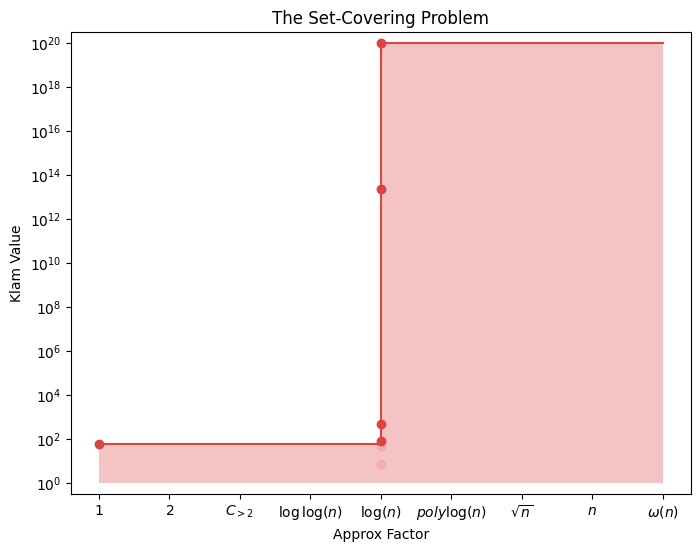

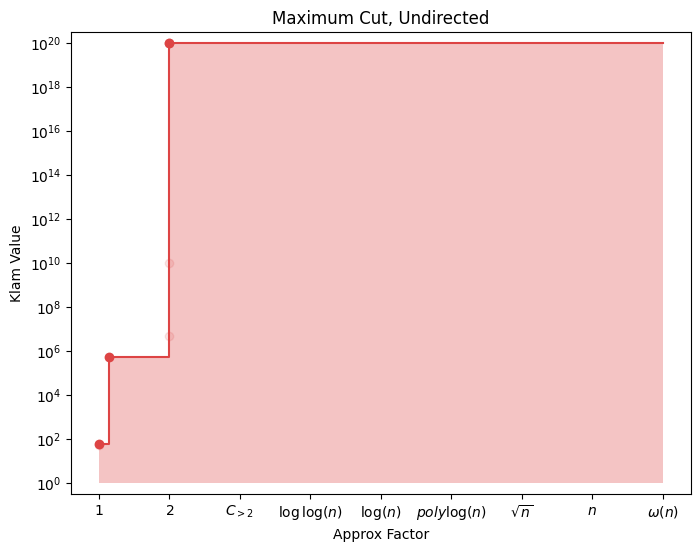

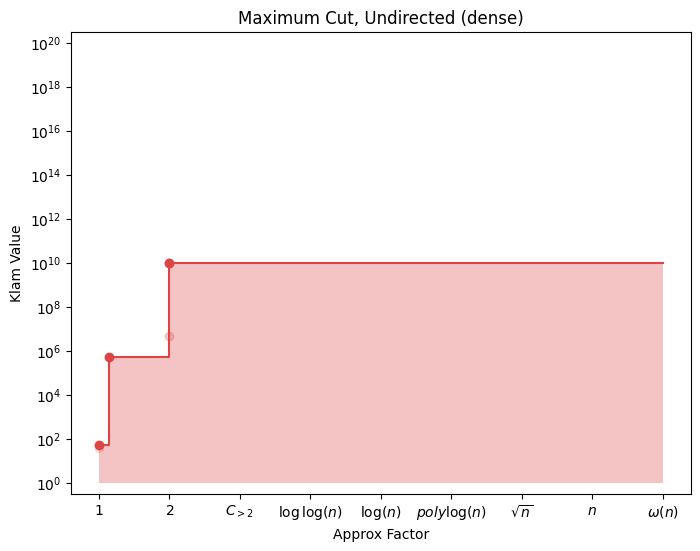

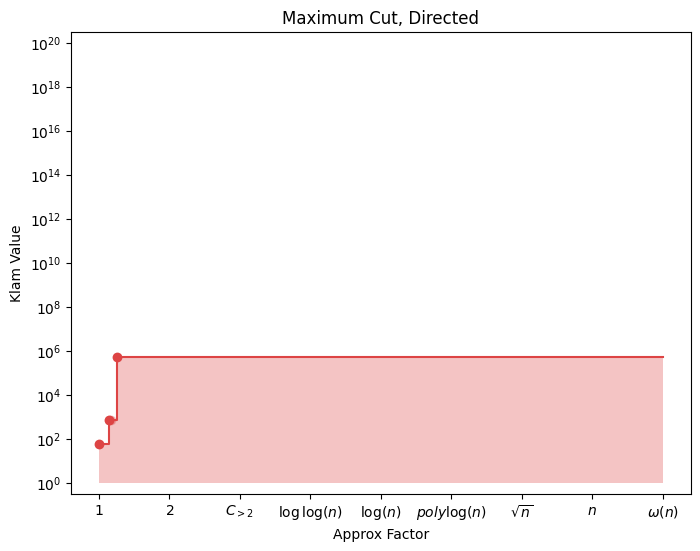

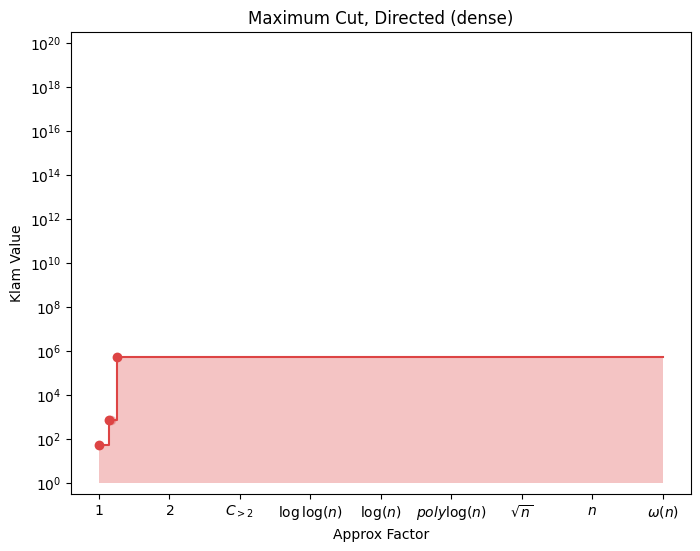

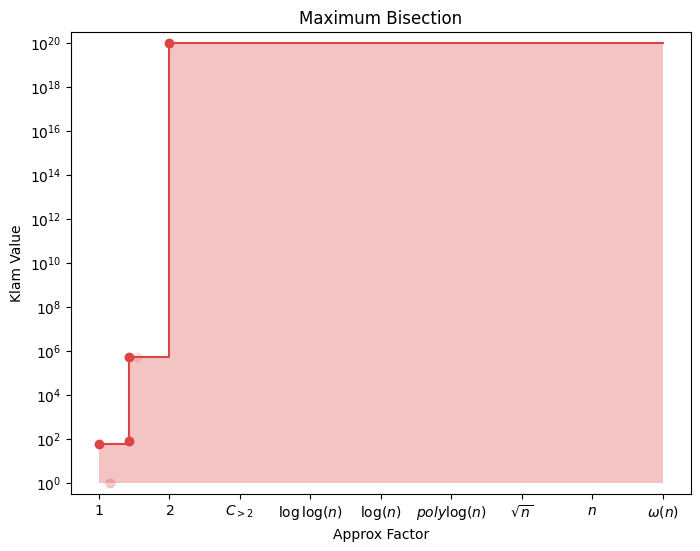

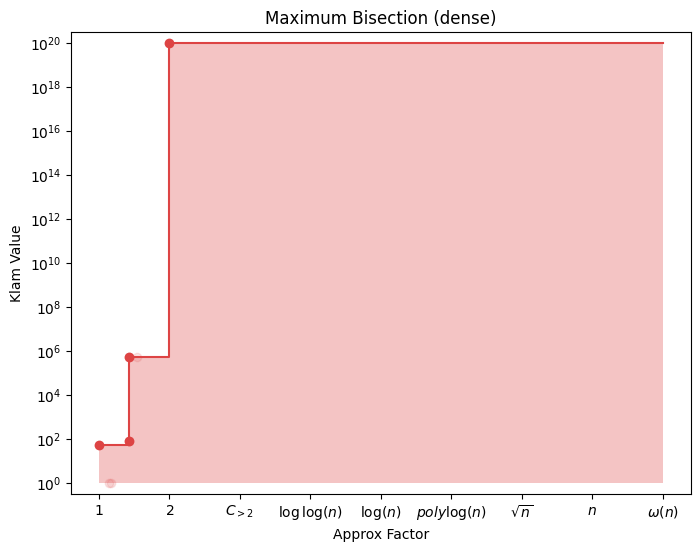

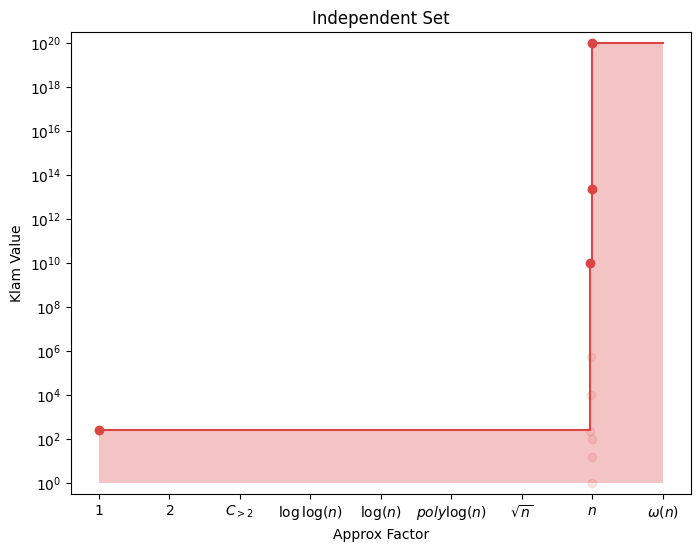

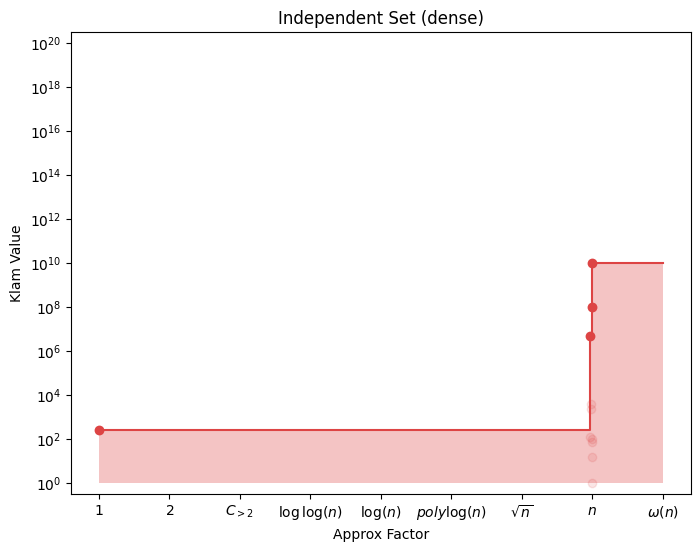

In [5]:
for family in approximation_algorithms['Problem Name'].unique():
    
    df = approximation_algorithms.copy()

    df = df[df['Problem Name'] == family]
    df = df[df['Graph-based?'] == "Y"]
    
    plot_family_only_20(family)
    if not df.empty:
        plot_family_only_20(family, True)

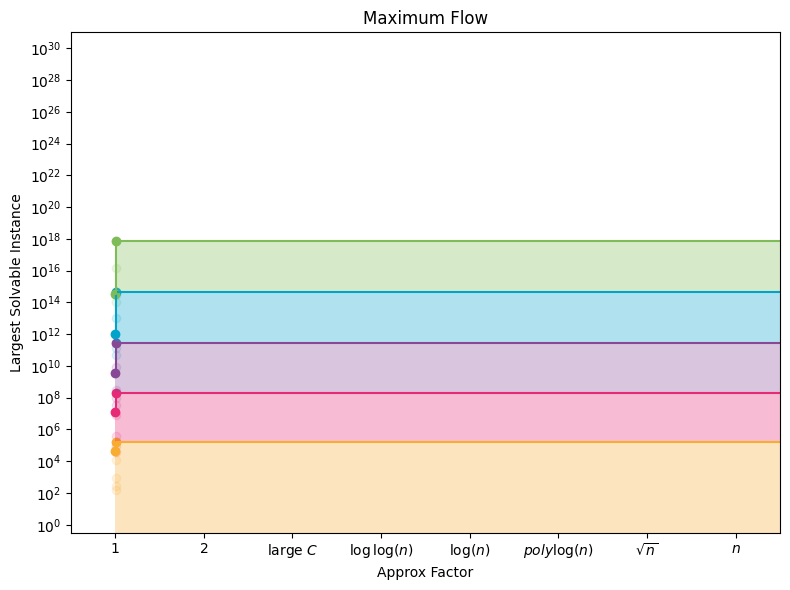

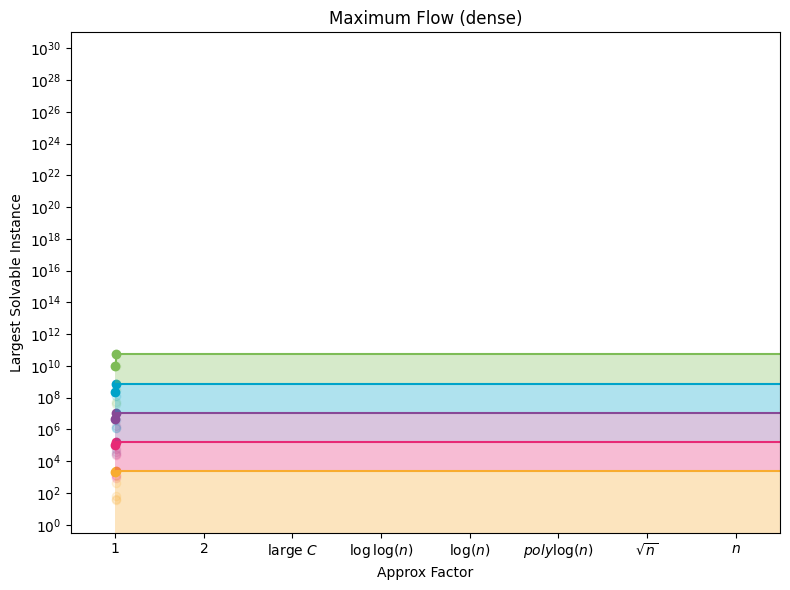

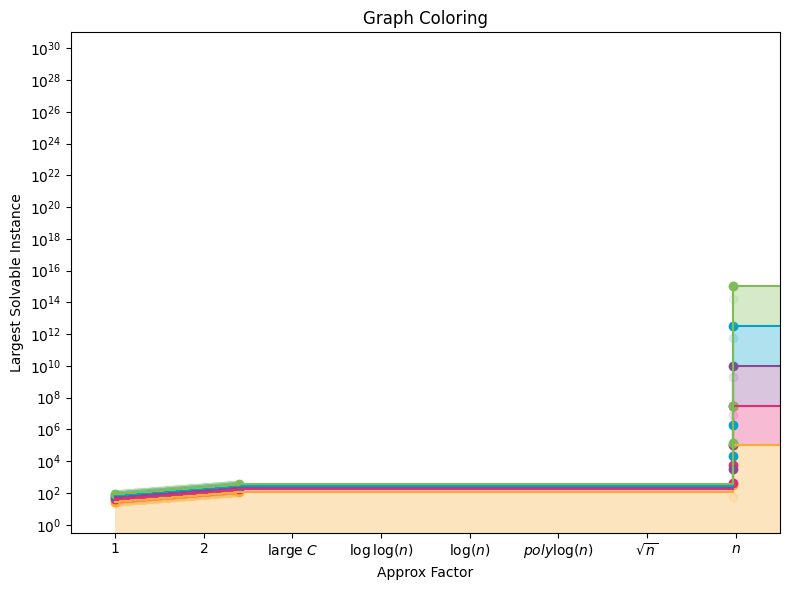

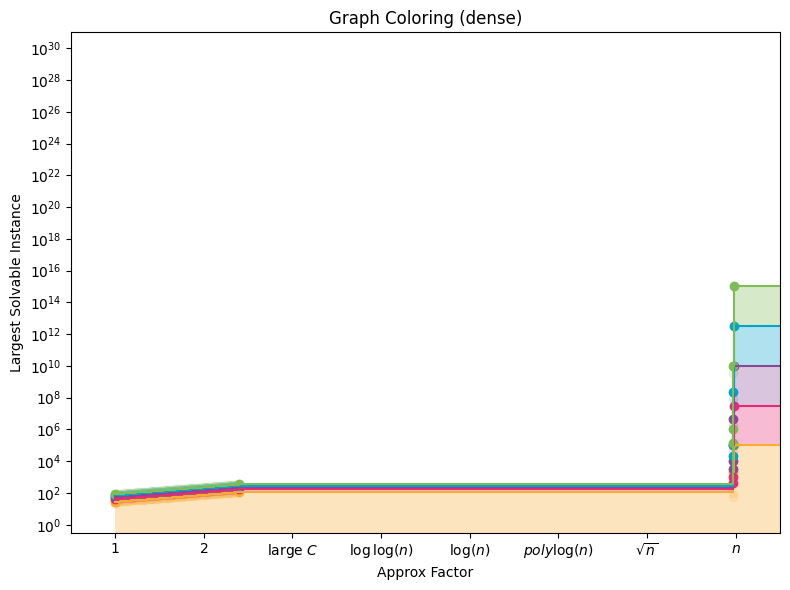

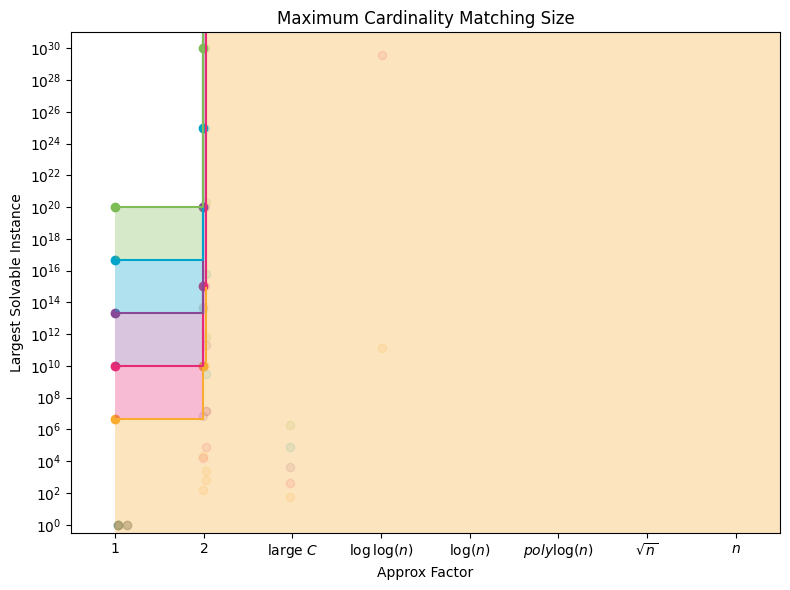

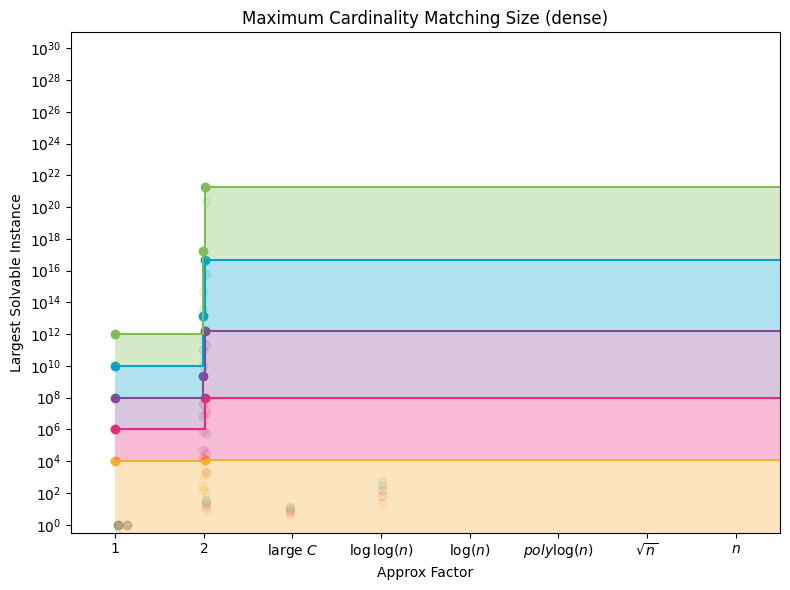

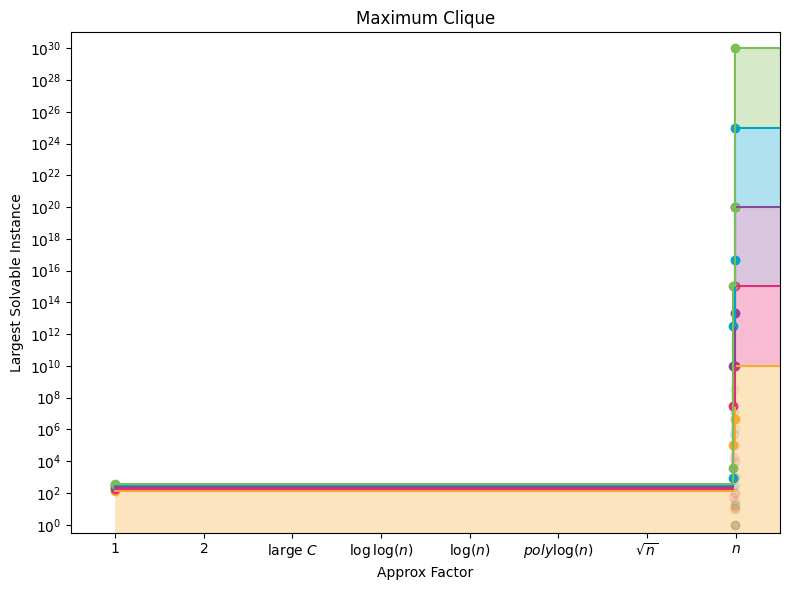

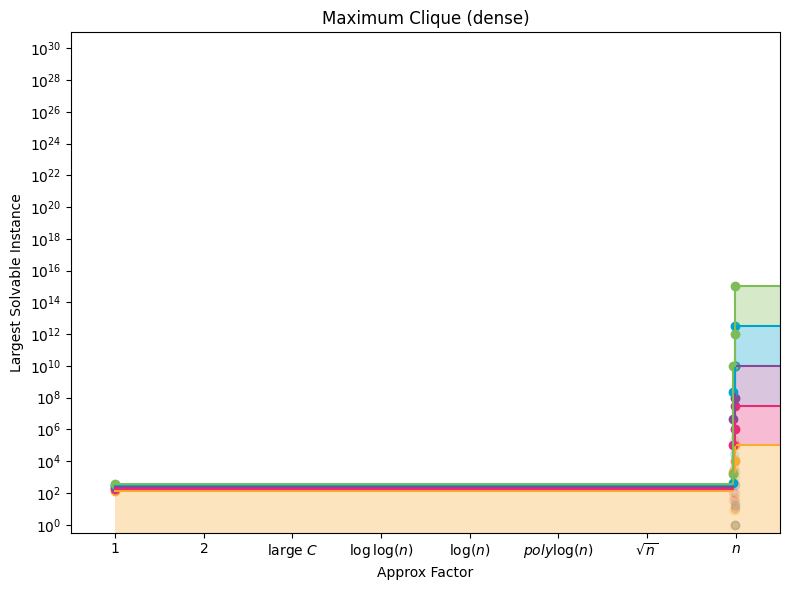

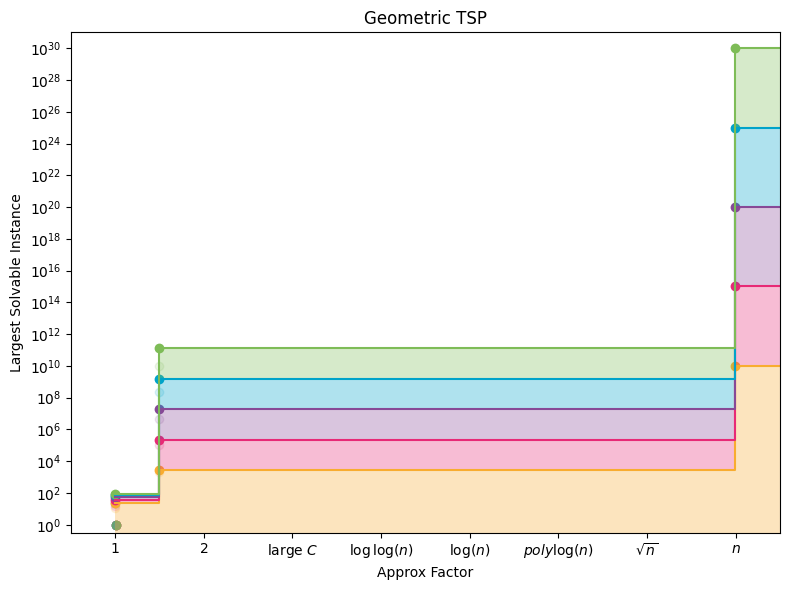

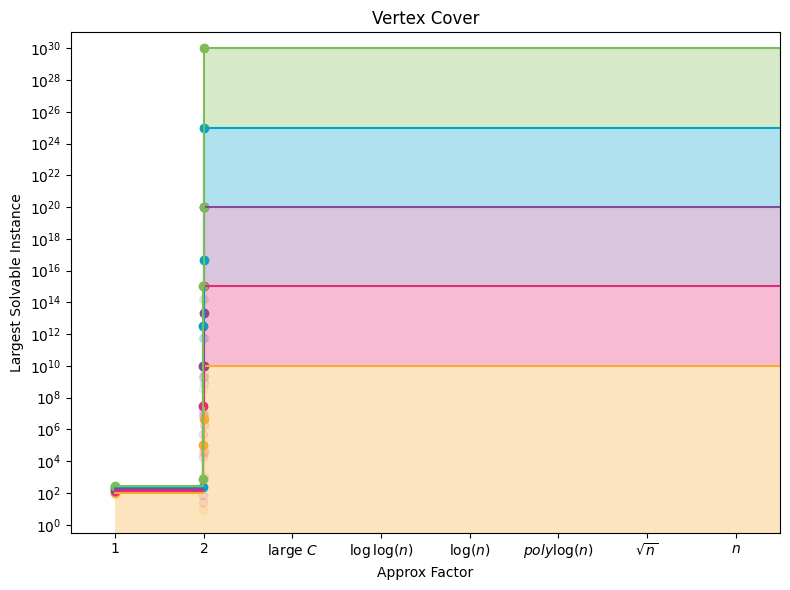

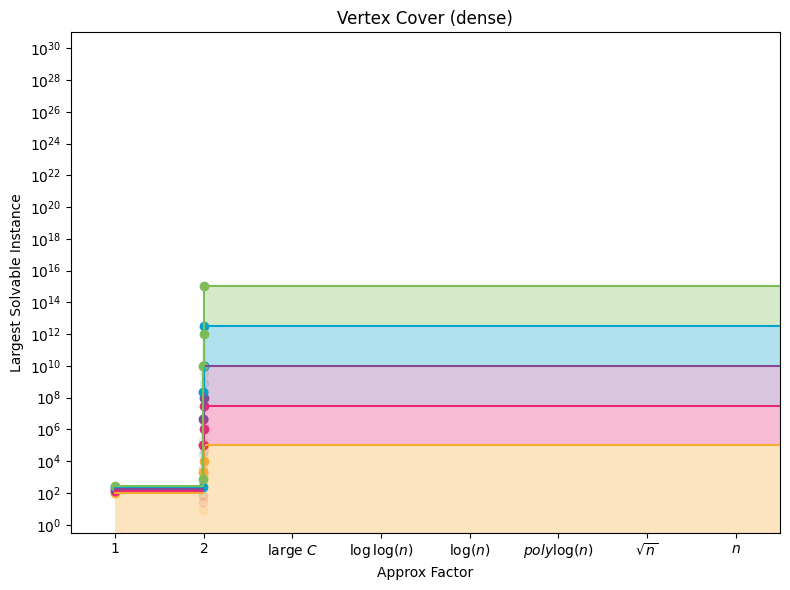

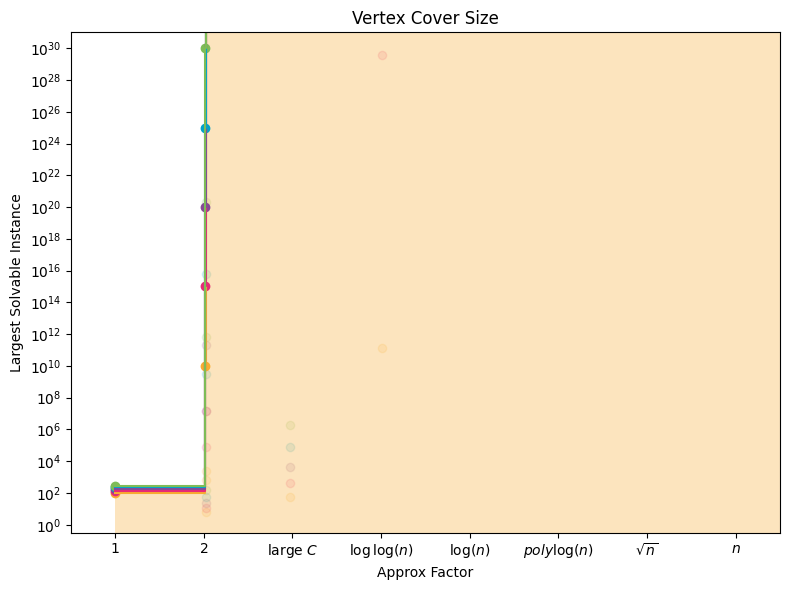

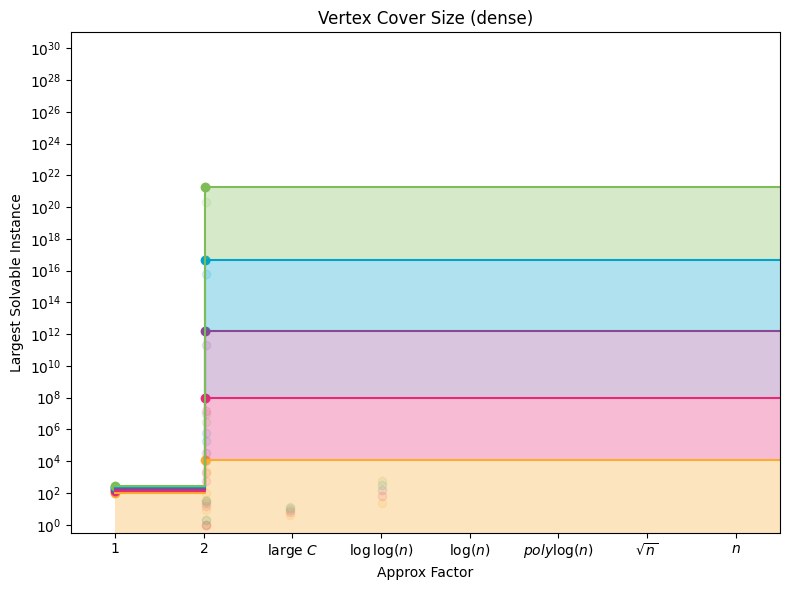

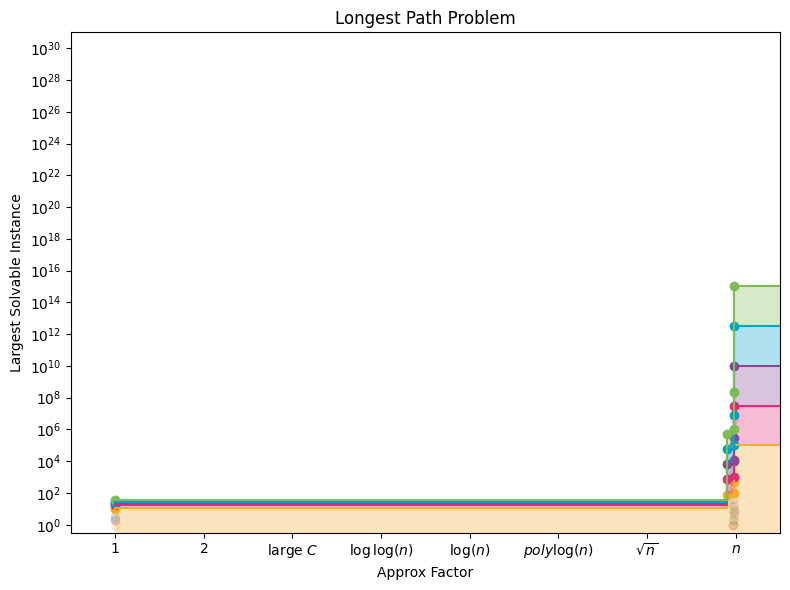

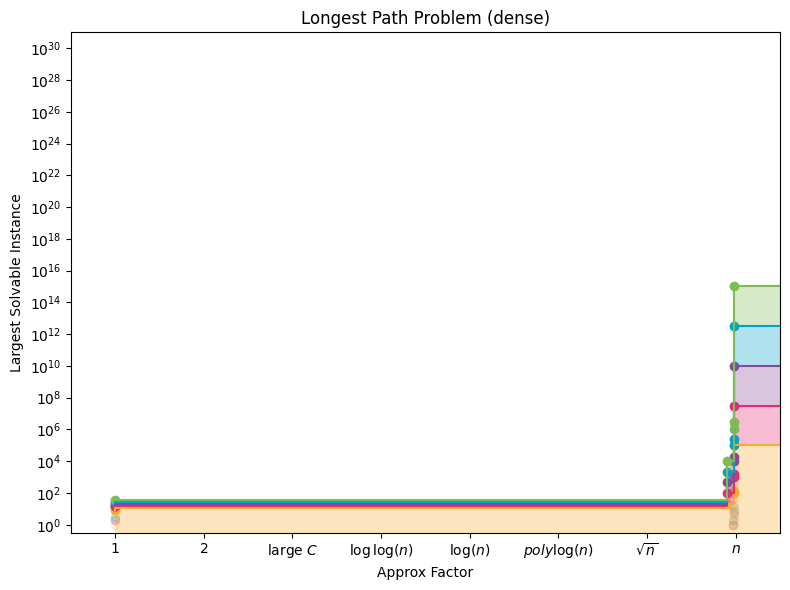

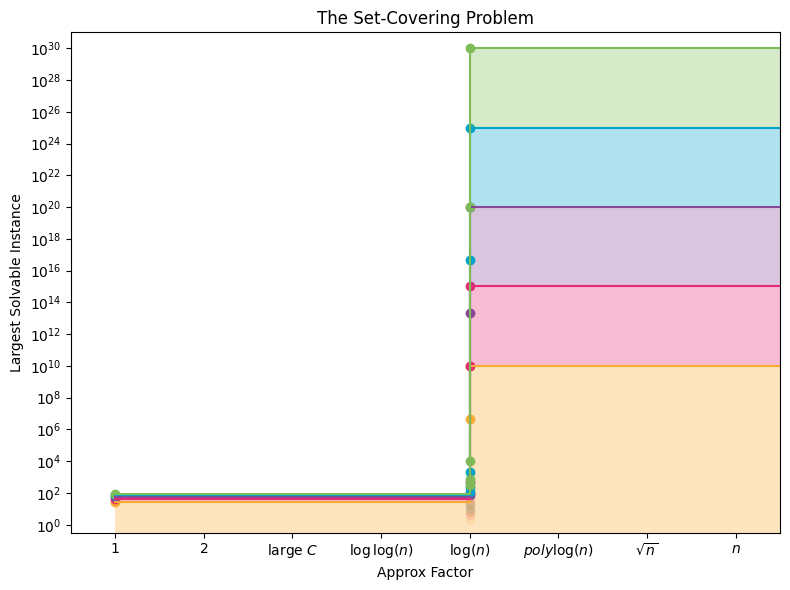

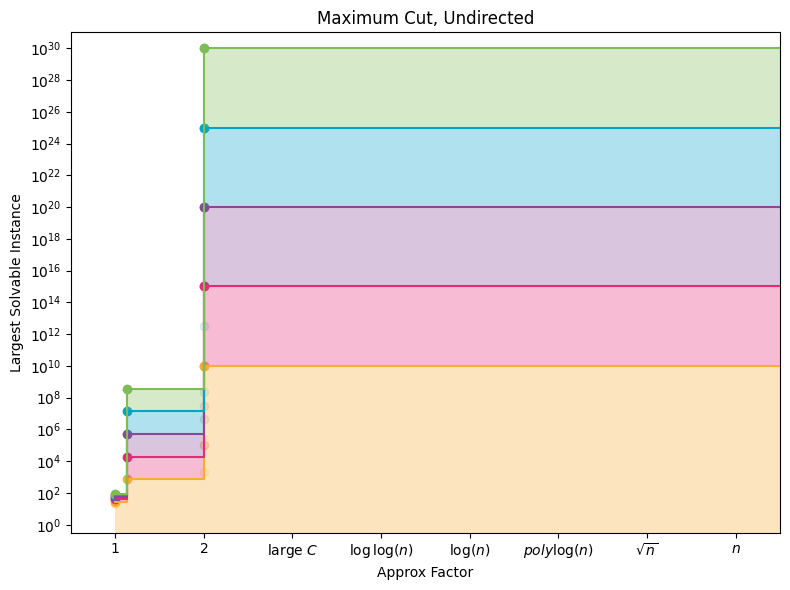

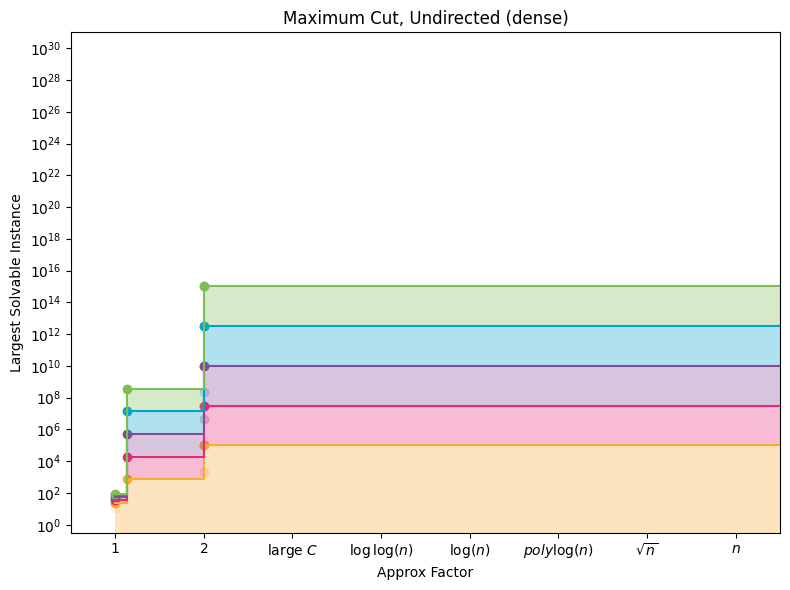

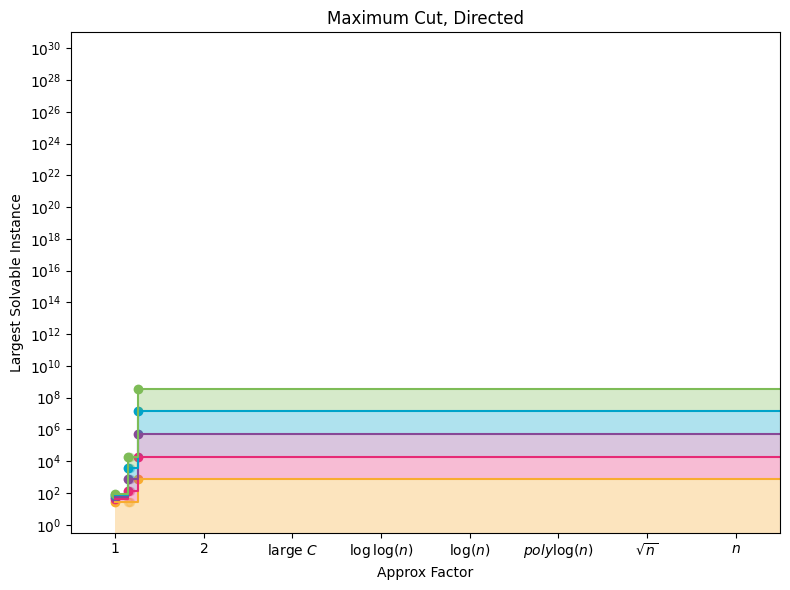

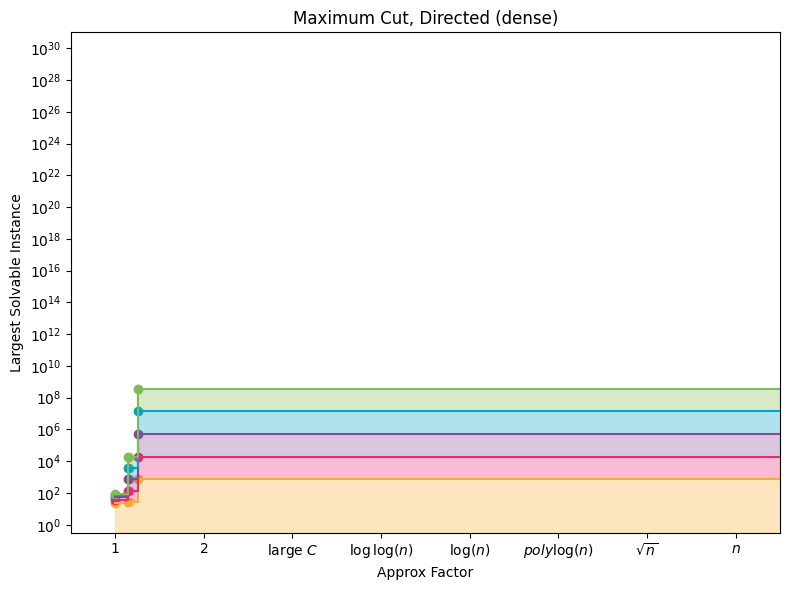

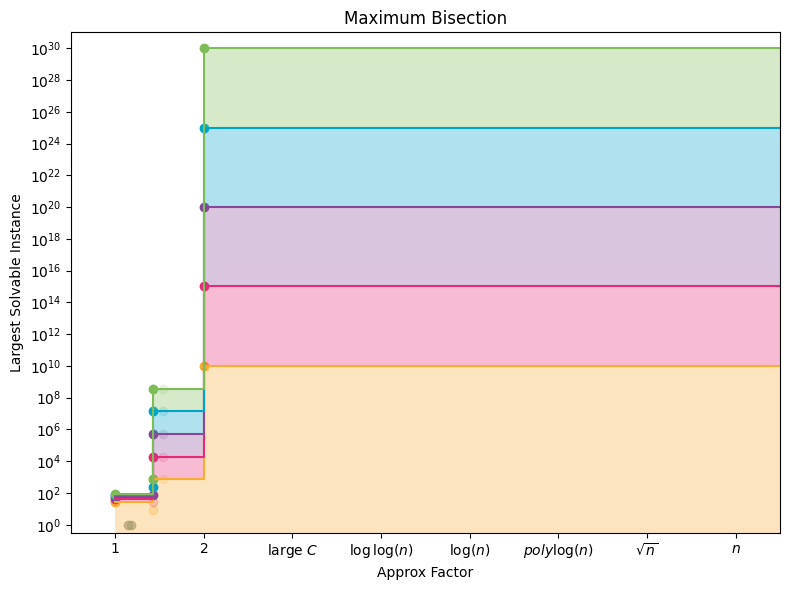

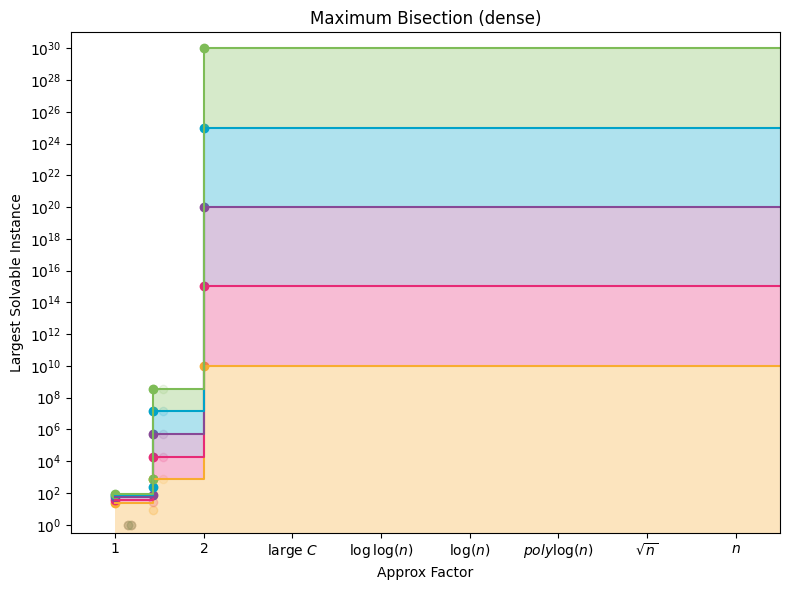

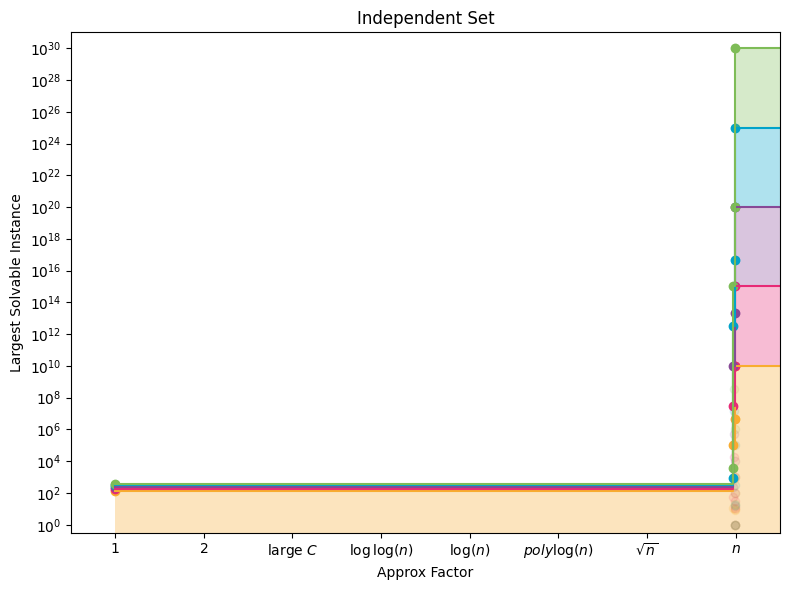

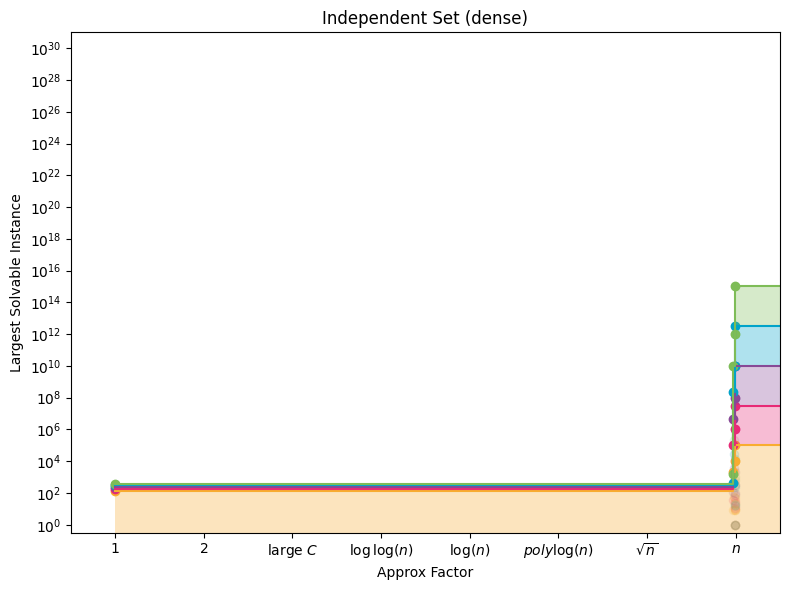

In [52]:
for family in approximation_algorithms['Problem Name'].unique():
    
    df = approximation_algorithms.copy()

    df = df[df['Problem Name'] == family]
    df = df[df['Graph-based?'] == "Y"]
    
    plot_family(family)
    if not df.empty:
        plot_family(family, True)

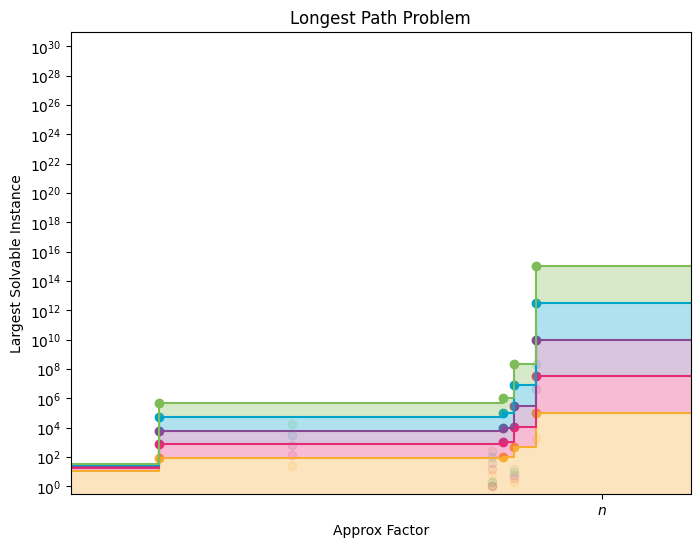

In [53]:
plot_family_no_save("Longest Path Problem", False, 7.88, 8.02)

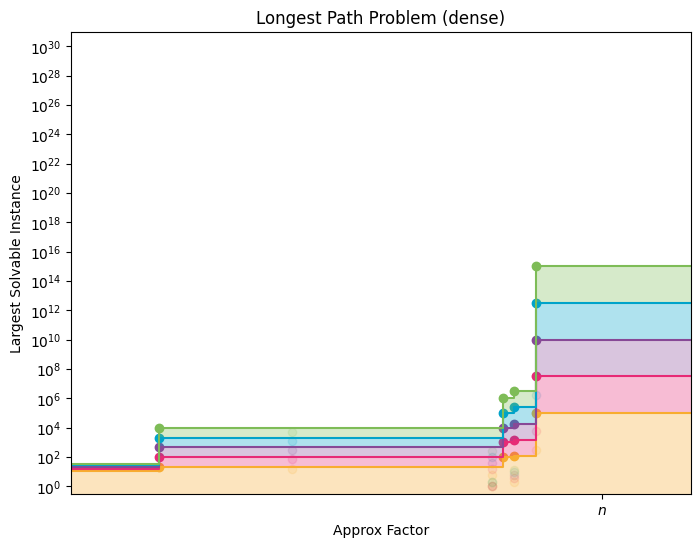

In [54]:
plot_family_no_save("Longest Path Problem", True, 7.88, 8.02)

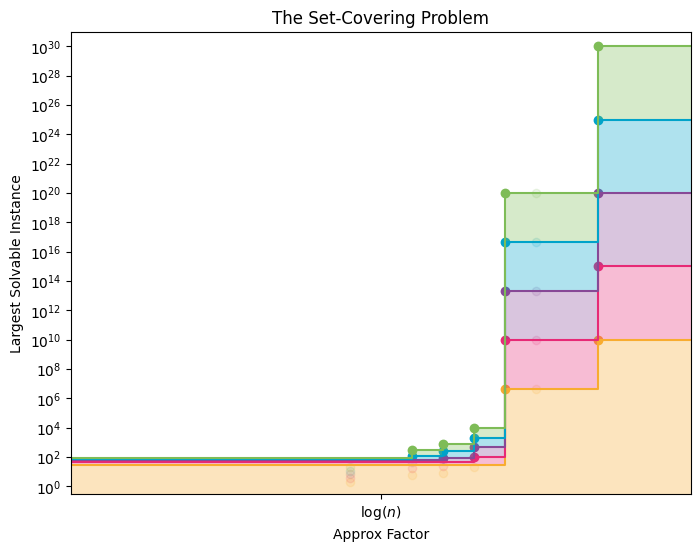

In [55]:
plot_family_no_save("The Set-Covering Problem", False, 4.999, 5.001)

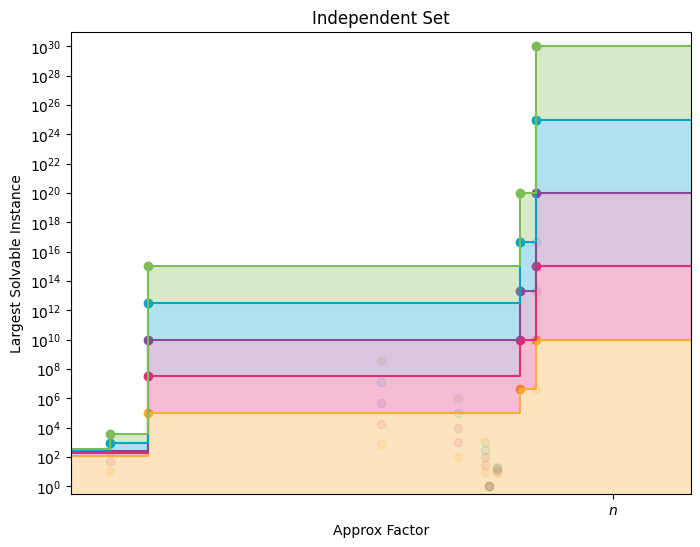

In [56]:
plot_family_no_save("Independent Set", False, 7.965, 8.005)

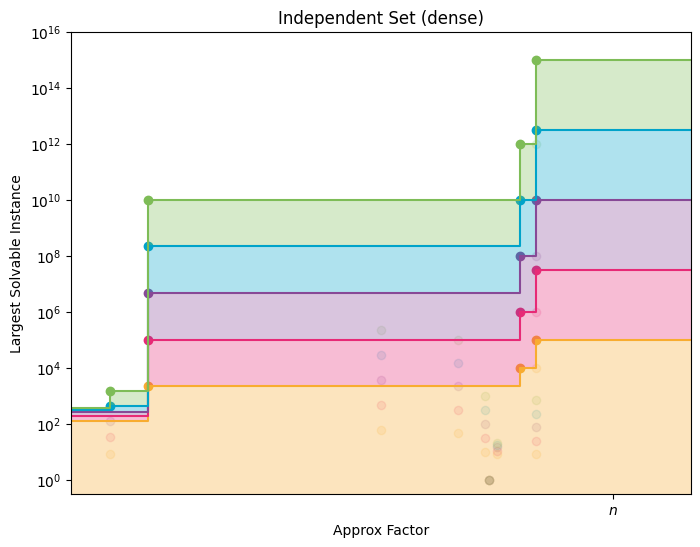

In [57]:
plot_family_no_save("Independent Set", True, 7.965, 8.005, -0.5, 16)

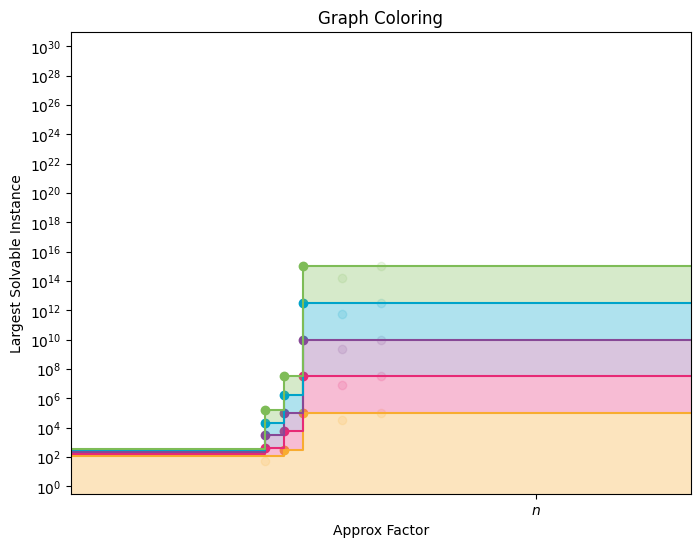

In [58]:
plot_family_no_save("Graph Coloring", False, 7.94, 8.02)

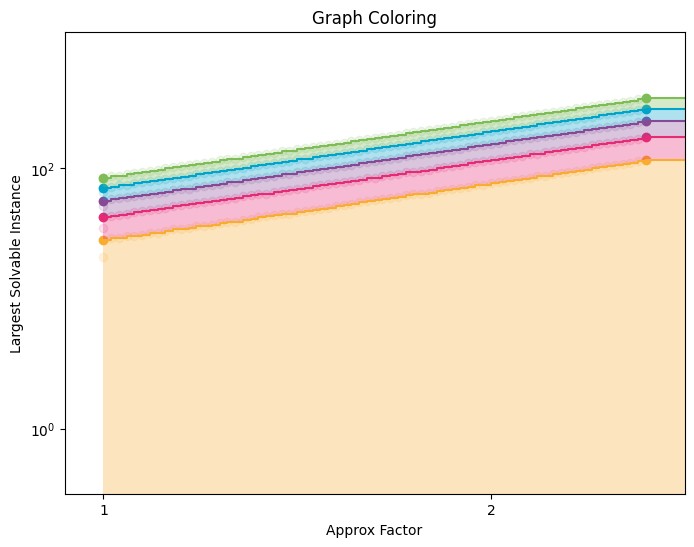

In [59]:
plot_family_no_save("Graph Coloring", False, 0.9, 2.5, -0.5, 3.05)

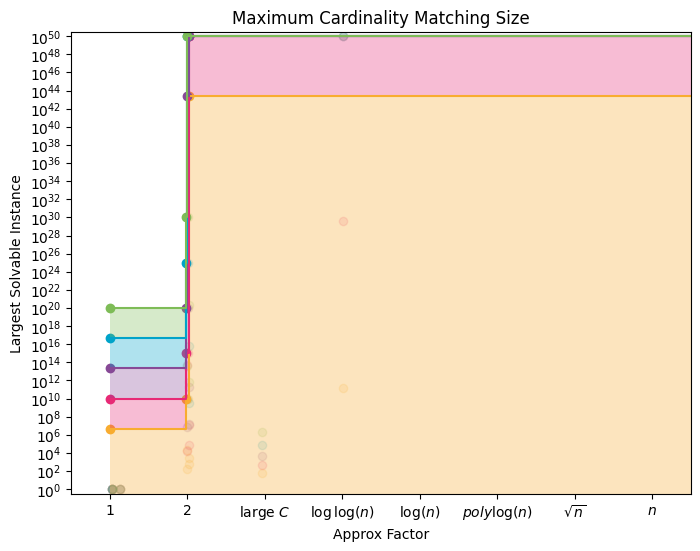

In [60]:
plot_family_no_save("Maximum Cardinality Matching Size", False, 0.5, 8.5, -0.5, 50.5)

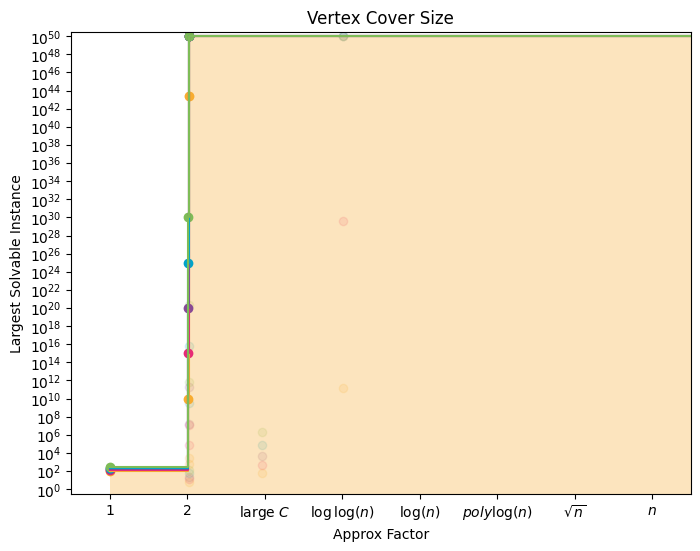

In [61]:
plot_family_no_save("Vertex Cover Size", False, 0.5, 8.5, -0.5, 50.5)

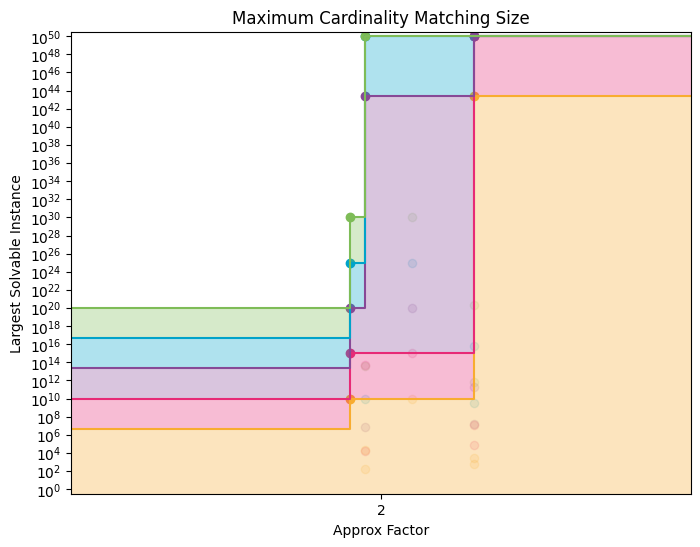

In [7]:
plot_family_no_save("Maximum Cardinality Matching Size", False, 1.9, 2.1, -0.5, 50.5)

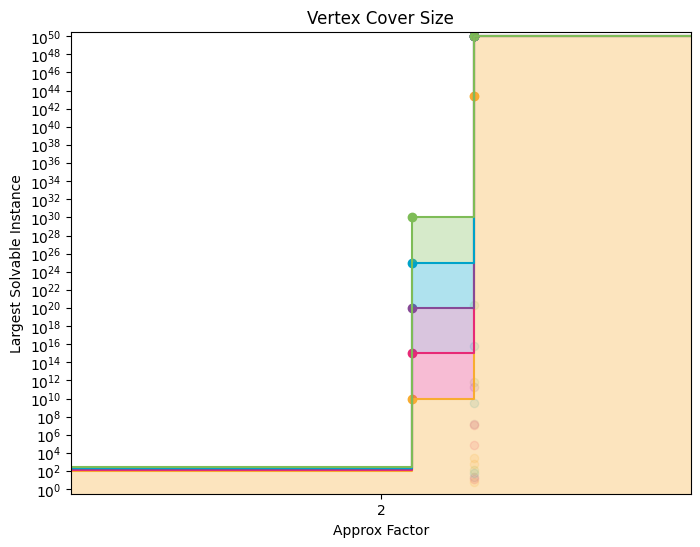

In [63]:
plot_family_no_save("Vertex Cover Size", False, 1.9, 2.1, -0.5, 50.5)